## Lesson 7: Statistics

## 1. Setup

In this block, we import libraries for data analysis, visualization, and statistical testing. We also mount Google Drive to access the dataset.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


## 2. Data Loading
Load the dataset and inspect the first rows to understand its structure.

In [34]:
df = pd.read_excel("gdrive/My Drive/Quest/ecommerce_conversion.xlsx")
df.head()

,user_id,device,country,time_on_site,pages,converted
0,1,mobile,DE,8.872778,6,1
1,2,desktop,UK,7.711163,11,0
2,3,desktop,DE,10.181250,11,1
3,4,mobile,DE,10.587142,1,0
4,5,mobile,US,7.254223,3,0


## 3. Data Overview

Perform basic analysis:

* data structure
* dataset size
* summary statistics

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       1000 non-null   int64  
 1   device        1000 non-null   object 
 2   country       1000 non-null   object 
 3   time_on_site  1000 non-null   float64
 4   pages         1000 non-null   int64  
 5   converted     1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [36]:
df.shape

(1000, 6)

In [37]:
df.describe()

,user_id,time_on_site,pages,converted
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.106634,7.698000,0.549000
std,288.819436,7.015983,3.982544,0.497842
min,1.000000,0.161740,1.000000,0.000000
25%,250.750000,5.009045,4.000000,0.000000
50%,500.500000,8.590447,8.000000,1.000000
75%,750.250000,13.278948,11.000000,1.000000
max,1000.000000,68.051163,14.000000,1.000000


In [38]:
# user_id      | User identifier
# device       | User device (mobile, desktop)
# country      | User country
# time_on_site | Time spent on the website
# pages        | Number of pages viewed
# converted    | Target variable (1 = purchase, 0 = no purchase)

## 4. Target Analysis

Calculate the main metric (conversion rate).

In [39]:
conversion_rate = df["converted"].mean()
print("Conversion rate:", conversion_rate)

Conversion rate: 0.549


In [40]:
# This is the baseline probability of purchase. If it is low, there is room for improvement

## 5. Segment Analysis

Compare conversion across user segments.

In [41]:
device_stats = df.groupby("device")["converted"].mean()
country_stats = df.groupby("country")["converted"].mean()

print(device_stats)
print(country_stats)

device
desktop    0.540052
mobile     0.554649
Name: converted, dtype: float64
country
DE    0.544304
UK    0.568513
US    0.533724
Name: converted, dtype: float64


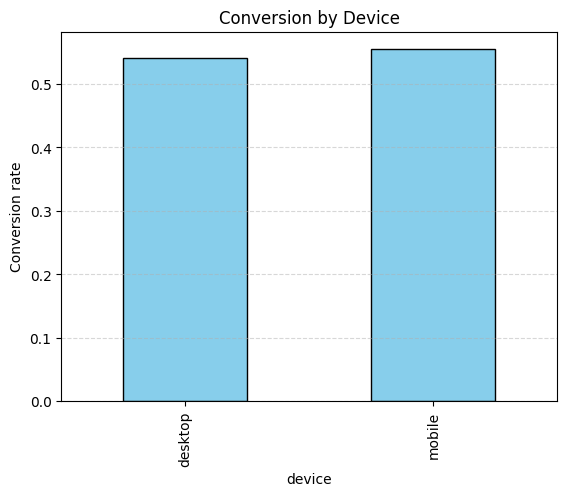

In [42]:
# Plot by device
device_stats.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Conversion by Device")
plt.ylabel("Conversion rate")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [43]:
# No strong differences -> device is not a key factor

## 6. Conditional Probabilities

Compute conditional probabilities to verify feature impact.

In [44]:
p_mobile = df[df["device"] == "mobile"]["converted"].mean()
p_desktop = df[df["device"] == "desktop"]["converted"].mean()

print("Mobile:", p_mobile)
print("Desktop:", p_desktop)

Mobile: 0.5546492659053833
Desktop: 0.5400516795865633


In [45]:
# Probabilities are close -> confirms weak impact of device

## 7. Distributions

Analyze distributions of key features.

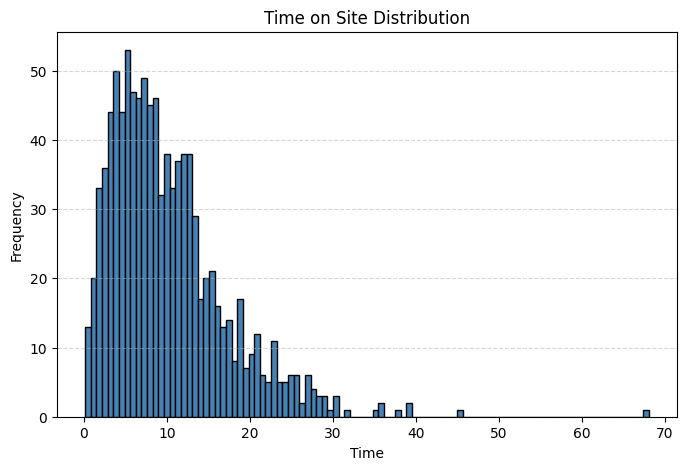

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df["time_on_site"], bins=100, color="steelblue", edgecolor="black")
plt.title("Time on Site Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

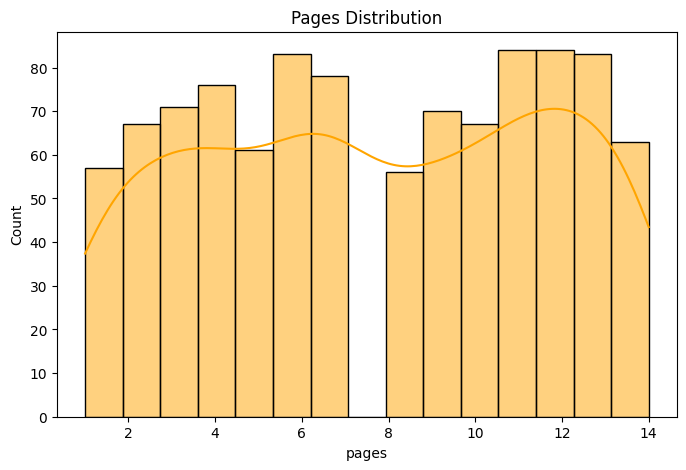

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df["pages"], bins=15, kde=True, color="orange")
plt.title("Pages Distribution")
plt.show()

In [48]:
# There is variability in behavior across users

## 8. Relationship with Target

Compare behavior across target groups.

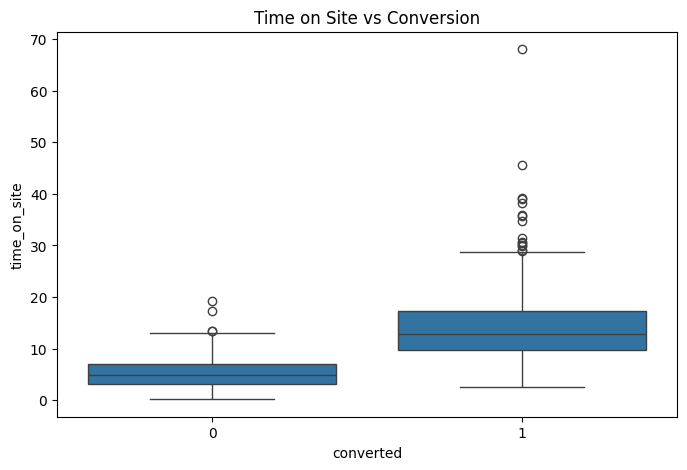

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x="converted", y="time_on_site", data=df)
plt.title("Time on Site vs Conversion")
plt.show()

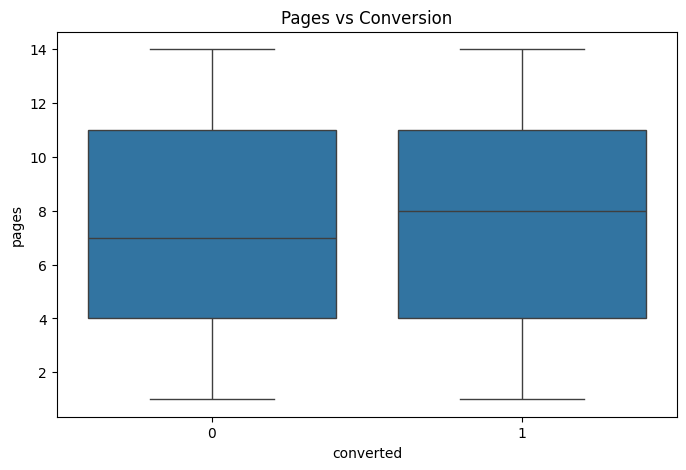

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(x="converted", y="pages", data=df)
plt.title("Pages vs Conversion")
plt.show()

In [51]:
# Converted users spend more time -> potential relationship

## 9. Correlation Analysis

Evaluate linear relationships between variables.

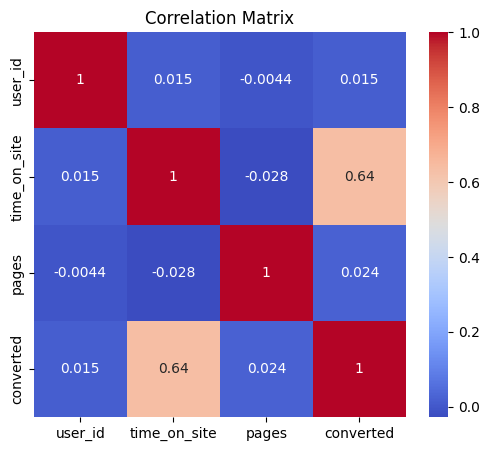

In [52]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [53]:
print(corr["converted"].sort_values())

user_id         0.014512
pages           0.024132
time_on_site    0.635158
converted       1.000000
Name: converted, dtype: float64


In [54]:
# time_on_site shows the strongest relationship -> main candidate factor

## 10. Feature Engineering

Create a feature to split users into groups.

In [55]:
threshold = df["time_on_site"].median()
df["high_time"] = df["time_on_site"] > threshold

In [56]:
# Users are divided into low and high time groups

## 11. Group Comparison
Compare conversion between groups.

In [57]:
group_stats = df.groupby("high_time")["converted"].mean()
print(group_stats)

high_time
False    0.202
True     0.896
Name: converted, dtype: float64


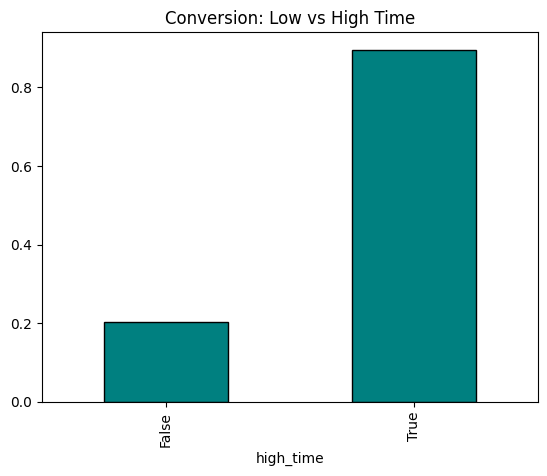

In [58]:
group_stats.plot(kind="bar", color="teal", edgecolor="black")
plt.title("Conversion: Low vs High Time")
plt.show()

In [59]:
# High-time group has higher conversion -> effect observed

## 12. Hypothesis Definition
Define hypotheses for statistical testing.

1.   Null hypothesis (H0): *Time on site does not affect purchase probability*

2.   Alternative hypothesis (H1): *Time on site affects purchase probability*



## 13. Prepare Groups
Split data into groups for testing.

In [60]:
low = df[df["high_time"] == False]["converted"]
high = df[df["high_time"] == True]["converted"]

print("Low:", low.mean())
print("High:", high.mean())

Low: 0.202
High: 0.896


In [61]:
# There is a difference -> needs statistical validation

## 14. Statistical Test
Perform a t-test to evaluate the hypothesis.

In [62]:
stat, p_value = ttest_ind(low, high, equal_var=False)

print("p-value:", p_value)

p-value: 8.441015084624434e-144


In [63]:
if p_value < 0.05:
    print("The difference is statistically significant")
else:
    print("The difference is not significant")

The difference is statistically significant


In [64]:
# If p-value < 0.05 -> reject H0 -> factor has real effect

## 15. Conclusion
Formulate final conclusions and practical recommendations.

*   Users who spend more time on the site are more likely to convert
*   Recommendation: increase user engagement (UX, content, recommendations)



